In [80]:
# Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.model_selection import train_test_split

In [ ]:
class LinearRegressionGD_AhmedWael:

    def __init__(self , lr , n_iters):
        self.learning_rate = lr
        self.gd_iterations = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.MSE = []
        self.SSE = []
        self.y_hat = None

    def gradiant_descent(self, x , y , y_hat):
        delta_theta_0 = 2 * np.mean((y_hat - y) * x)
        delta_theta_1 = 2 * np.mean((y_hat - y))

        return delta_theta_0 , delta_theta_1

    def fit(self , x , y):

        for i in range(self.gd_iterations):

            y_hat = self.theta_0 * x + self.theta_1

            sse = (np.sum((y_hat - y)**2))
            self.SSE.append(sse)

            delta_theta_0 , delta_theta_1 = self.gradiant_descent(x , y , y_hat)

            self.theta_0 -= self.learning_rate * delta_theta_0
            self.theta_1 -= self.learning_rate * delta_theta_1

            if i %20 == 0:
                print(f"No.of iters is {i}\nSSE is {sse}\nTheta_0 is {self.theta_0}\ntheta_1 is {self.theta_1}")
                print('-'*20)

    def predict(self , x):

        y_hat = self.theta_0 * x + self.theta_1
        self.y_hat = y_hat
        return y_hat
    

    def plot_training(self , x , y):
        
        plt.figure(figsize=(14,2))
        plt.subplot(1,2,1)
        plt.plot(self.SSE , label="SSE")
        plt.xlabel('num of iterations')
        plt.ylabel('SSE values')
        plt.title('SEE over iteration')
        plt.legend()

        plt.subplot(1,2,2)
        plt.scatter(x, y, color="blue", alpha=0.7, label="Data points")
        plt.plot(x, self.predict(x), color="red", label="Regression line")
        plt.xlabel("house area") 
        plt.ylabel("price") 
        plt.title("house area vs price (with Regression Line)") 
        plt.legend()
        plt.show()

##### Question 1, what is the theta_0, theta_1

 Short answer => theta_0 is the Slope -> w
 theta_1 is the Intercept -> b

That brings the equation to theta_0 * X + theta_1 = y_hat

In [82]:
# data and modifers preparation

x = np.array([50,60,70,80,90])
y = np.array([150 , 180 , 210 , 240 , 270])
learning_rate = 0.001
n_iters = 100


model = LinearRegressionGD_AhmedWael(learning_rate , n_iters)

model.fit(x , y)

y_pred = model.predict(x)

test = np.array([70])

y_pred_test = model.predict(test)


print(y_pred)
print(y_pred_test)


No.of iters is 0
SSE is 229500
Theta_0 is 30.6
theta_1 is 0.42
--------------------
No.of iters is 20
SSE is 8.239935436657963e+43
Theta_0 is 5.229841567936853e+20
theta_1 is 7.178269102604904e+18
--------------------
No.of iters is 40
SSE is 2.958454731965587e+82
Theta_0 is 9.909667719041093e+39
theta_1 is 1.3601609280247472e+38
--------------------
No.of iters is 60
SSE is 1.0621993908048742e+121
Theta_0 is 1.8777148987430063e+59
theta_1 is 2.5772755572144633e+57
--------------------
No.of iters is 80
SSE is 3.813705626912284e+159
Theta_0 is 3.5579530423474464e+78
theta_1 is 4.883502503973016e+76
--------------------
[-3.66421924e+98 -4.39686197e+98 -5.12950470e+98 -5.86214743e+98
 -6.59479016e+98]
[-5.1295047e+98]


#### Question 2 
after using the test of 70m2 it's not reasonable, the cause is the low iterations and maybe the learning rate is not low enough, so we will lower the learning rate to be 0.0001 and we will try these values in iterations [200 , 300 , 500 , 1000 , 5000 , 10000]

and we will predict again

In [83]:
x = np.array([50,60,70,80,90])
y = np.array([150 , 180 , 210 , 240 , 270])
learning_rate = 0.0001
n_iters = 100


model = LinearRegressionGD_AhmedWael(learning_rate , n_iters)

model.fit(x , y)

y_pred = model.predict(x)

test = np.array([70])

y_pred_test = model.predict(test)


print(y_pred)
print(y_pred_test)

No.of iters is 0
SSE is 229500
Theta_0 is 3.06
theta_1 is 0.042
--------------------
No.of iters is 20
SSE is 0.0003322269778211089
Theta_0 is 2.9994350235666287
theta_1 is 0.041162252263296464
--------------------
No.of iters is 40
SSE is 0.00033212278531473746
Theta_0 is 2.999435112167089
theta_1 is 0.041155797136480224
--------------------
No.of iters is 60
SSE is 0.00033201862548500397
Theta_0 is 2.9994352007536556
theta_1 is 0.04114934302196676
--------------------
No.of iters is 80
SSE is 0.0003319144983204152
Theta_0 is 2.9994352893263296
theta_1 is 0.041142889919597324
--------------------
[150.01290543 180.00725917 210.0016129  239.99596664 269.99032037]
[210.0016129]


#### After Observation 
We saw that the crucial point from not getting a reasonable data was the learning rate of 0.001, we decreased it to 0.0001 and with the same iterations, and it gave us and SSE of 0.0003 , and a reasonable prediction, we can even lower the iterations as well

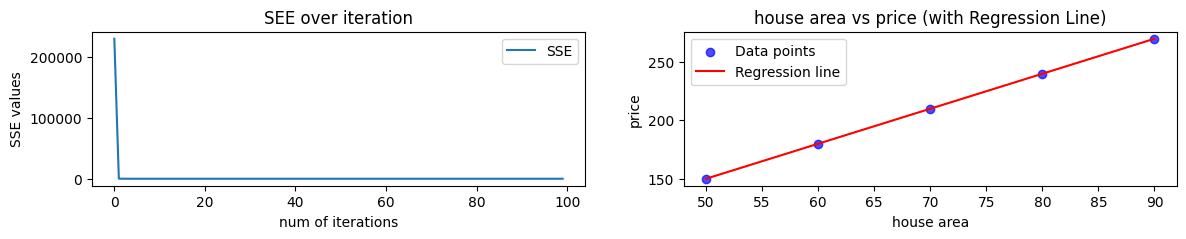

In [84]:
model.plot_training(x , y)

### As part of the assignment to do experimentation we will start to train the model with very large learning rate and very small learning rate

#### to demonstrate it we will make an array of 7 values for the learning rate and use it in a loop, on each iteration we will visualiza the SSE over Iteration and the regression line to demonstrate the effect of the learning rate

No.of iters is 0
SSE is 229500
Theta_0 is 30600.0
theta_1 is 420.0
--------------------
No.of iters is 20
SSE is 5.085797358495204e+165
Theta_0 is 4.554776121880026e+84
theta_1 is 6.251701563088108e+82
--------------------
No.of iters is 40
SSE is inf
Theta_0 is 6.780398459768393e+164
theta_1 is 9.306500805971068e+162
--------------------
No.of iters is 60
SSE is inf
Theta_0 is 1.0093537430387121e+245
theta_1 is 1.3853981412503242e+243
--------------------
No.of iters is 80
SSE is nan
Theta_0 is nan
theta_1 is nan
--------------------
Learning rate: 1
Final SSE Value: nan


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_10688\632473394.py:24: RuntimeWarning: overflow encountered in square
  sse = (np.sum((y_hat - y)**2))
C:\Users\Ahmed\AppData\Local\Temp\ipykernel_10688\632473394.py:13: RuntimeWarning: overflow encountered in multiply
  delta_theta_0 = 2 * np.mean((y_hat - y) * x)
C:\Users\Ahmed\AppData\Local\Temp\ipykernel_10688\632473394.py:29: RuntimeWarning: invalid value encountered in scalar subtract
  self.theta_0 -= self.learning_rate * delta_theta_0


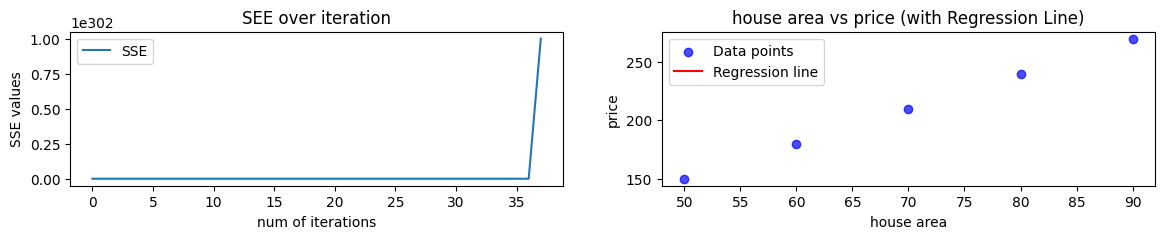

--------------------
No.of iters is 0
SSE is 229500
Theta_0 is 3060.0
theta_1 is 42.0
--------------------
No.of iters is 20
SSE is 4.9093684921066456e+125
Theta_0 is 4.471126828185279e+63
theta_1 is 6.136887924360499e+61
--------------------
No.of iters is 40
SSE is 1.0501916787011175e+246
Theta_0 is 6.53940838975294e+123
theta_1 is 8.975727578684004e+121
--------------------
No.of iters is 60
SSE is inf
Theta_0 is 9.564448455900298e+183
theta_1 is 1.3127775276284484e+182
--------------------
No.of iters is 80
SSE is inf
Theta_0 is 1.3988830305952143e+244
theta_1 is 1.9200502933478507e+242
--------------------
Learning rate: 0.1
Final SSE Value: inf


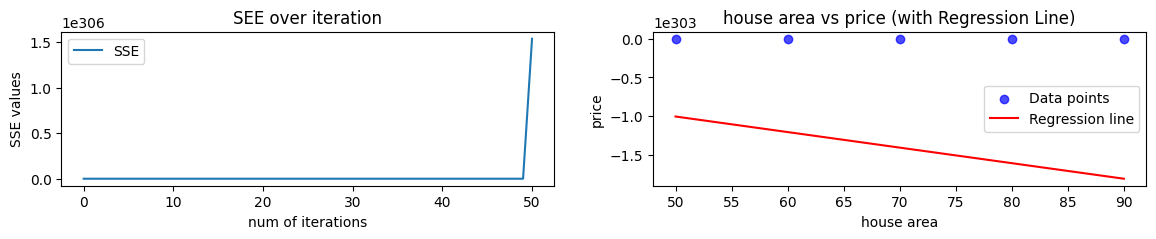

--------------------
No.of iters is 0
SSE is 229500
Theta_0 is 306.0
theta_1 is 4.2
--------------------
No.of iters is 20
SSE is 3.4430426909513855e+85
Theta_0 is 3.711276374678462e+42
theta_1 is 5.093947911330612e+40
--------------------
No.of iters is 40
SSE is 5.165378208662289e+165
Theta_0 is 4.545724971249044e+82
theta_1 is 6.239278319654552e+80
--------------------
No.of iters is 60
SSE is 7.749288763872596e+245
Theta_0 is 5.567792163155023e+122
theta_1 is 7.642126426837104e+120
--------------------
No.of iters is 80
SSE is inf
Theta_0 is 6.819662379084139e+162
theta_1 is 9.360392874250794e+160
--------------------
Learning rate: 0.01
Final SSE Value: inf


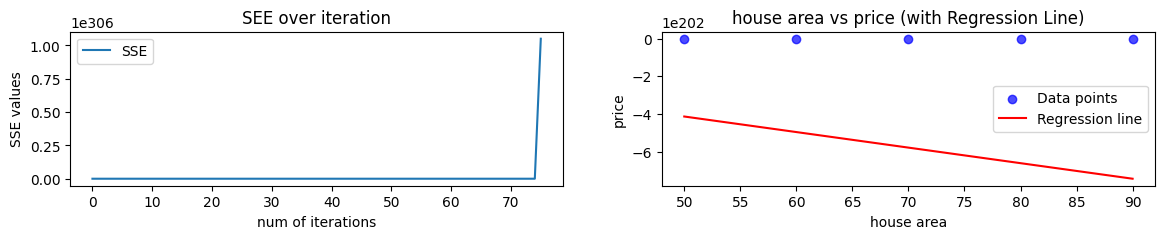

--------------------
No.of iters is 0
SSE is 229500
Theta_0 is 30.6
theta_1 is 0.42
--------------------
No.of iters is 20
SSE is 8.239935436657963e+43
Theta_0 is 5.229841567936853e+20
theta_1 is 7.178269102604904e+18
--------------------
No.of iters is 40
SSE is 2.958454731965587e+82
Theta_0 is 9.909667719041093e+39
theta_1 is 1.3601609280247472e+38
--------------------
No.of iters is 60
SSE is 1.0621993908048742e+121
Theta_0 is 1.8777148987430063e+59
theta_1 is 2.5772755572144633e+57
--------------------
No.of iters is 80
SSE is 3.813705626912284e+159
Theta_0 is 3.5579530423474464e+78
theta_1 is 4.883502503973016e+76
--------------------
Learning rate: 0.001
Final SSE Value: 1.6170789775172251e+196


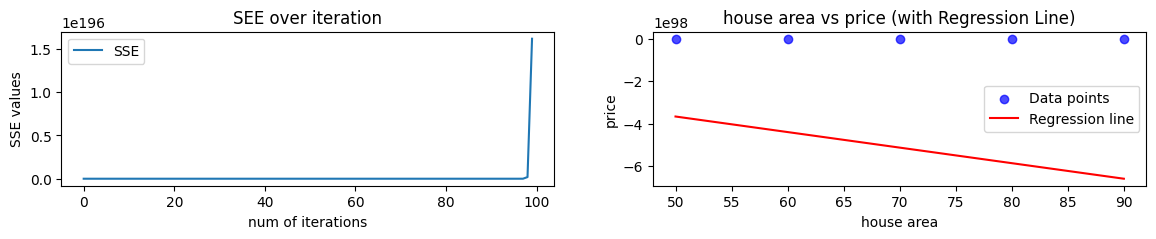

--------------------
No.of iters is 0
SSE is 229500
Theta_0 is 3.06
theta_1 is 0.042
--------------------
No.of iters is 20
SSE is 0.0003322269778211089
Theta_0 is 2.9994350235666287
theta_1 is 0.041162252263296464
--------------------
No.of iters is 40
SSE is 0.00033212278531473746
Theta_0 is 2.999435112167089
theta_1 is 0.041155797136480224
--------------------
No.of iters is 60
SSE is 0.00033201862548500397
Theta_0 is 2.9994352007536556
theta_1 is 0.04114934302196676
--------------------
No.of iters is 80
SSE is 0.0003319144983204152
Theta_0 is 2.9994352893263296
theta_1 is 0.041142889919597324
--------------------
Learning rate: 0.0001
Final SSE Value: 0.00033181560776546876


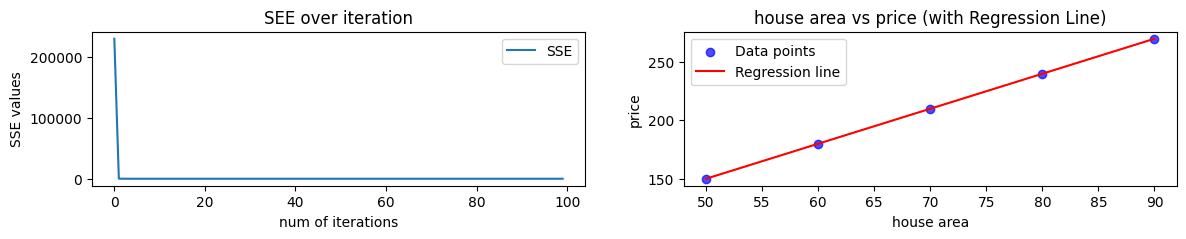

--------------------
No.of iters is 0
SSE is 229500
Theta_0 is 0.30600000000000005
theta_1 is 0.004200000000000001
--------------------
No.of iters is 20
SSE is 3100.7336963140633
Theta_0 is 2.6863606856254156
theta_1 is 0.03687122264839328
--------------------
No.of iters is 40
SSE is 41.89378507071959
Theta_0 is 2.9630444320596725
theta_1 is 0.04066822612016482
--------------------
No.of iters is 60
SSE is 0.5663472319365881
Theta_0 is 2.9952050674115336
theta_1 is 0.04110900423585668
--------------------
No.of iters is 80
SSE is 0.00797961581297281
Theta_0 is 2.998943300663654
theta_1 is 0.04115966796114595
--------------------
Learning rate: 1e-05
Final SSE Value: 0.00046041150816733306


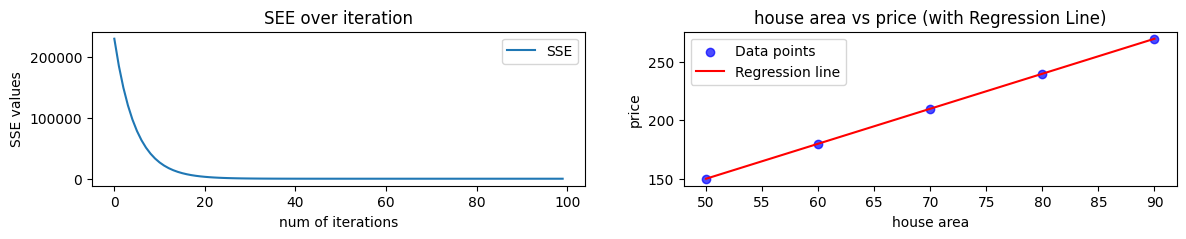

--------------------
No.of iters is 0
SSE is 229500
Theta_0 is 0.0306
theta_1 is 0.00041999999999999996
--------------------
No.of iters is 20
SSE is 152281.42910118218
Theta_0 is 0.5810903724823948
theta_1 is 0.00797574372003637
--------------------
No.of iters is 40
SSE is 101044.15537138388
Theta_0 is 1.029507151684081
theta_1 is 0.014130466565410081
--------------------
No.of iters is 60
SSE is 67046.39824243815
Theta_0 is 1.394777132664207
theta_1 is 0.019143950073323635
--------------------
No.of iters is 80
SSE is 44487.6747651862
Theta_0 is 1.6923176467734582
theta_1 is 0.02322780630093331
--------------------
Learning rate: 1e-06
Final SSE Value: 30130.806027135746


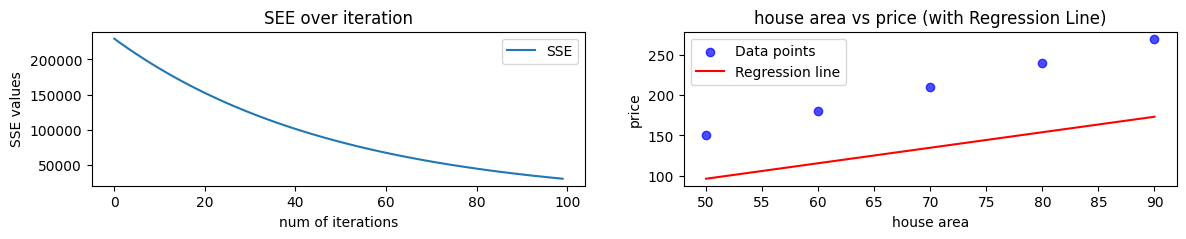

In [85]:
learning_rates = [1,0.1,0.01,0.001,0.0001,0.00001,0.000001]
# Fixed iteration count -> 100

n_iterations = 100

# the actual Data
x = np.array([50,60,70,80,90])
y = np.array([150 , 180 , 210 , 240 , 270])

for i in learning_rates:
    new_model = LinearRegressionGD_AhmedWael(i , n_iterations)
    new_model.fit(x , y)
    
    y_predict = new_model.predict(x)

    print(f'Learning rate: {i}\nFinal SSE Value: {new_model.SSE[-1]}')
    new_model.plot_training(x , y)
    if i != learning_rates[-1]:
        print('-'*20)

### observation

##### high learning rates have a bad effect on the linear regression model causing non-sense predictions, lowering the rates fixed the problem till a certain point, then the SSE raised up again when the learinng rate became significantlly low

### conclusion

##### it's important to try different learning rates and test it on the model to evalute the model and get the best fit line to use it for production